<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST


## Mecânica dos Sólidos I

## Torção de barras elásticas. Parte III
## Problema 1 <a name="PV131"></a>

A figura representa dois veios maciços $AB$ e $CD$, de diâmetros $\phi_{AB}$ = 30 mm e $\phi_{CD}$ = 35 mm, construídos em aço macio (que é considerado um material elastoplástico com $G =$ 77 GPa e $\tau_C$ = 175 MPa) e ligados pelas engrenagens $E$ e $F$. Os troços $AE$, $EB$, $CF$ e $FD$ têm um comprimento respectivamente igual a 200 mm, 100 mm, 120 mm e 300 mm. Considere que na extremidade $D$ está aplicado um momento de torção $T$ = 1720 N.m e que, devido a uma avaria, a extremidade $A$ está
bloqueada.

[a)](#A) Determine a distribuição de tensões tangenciais nos dois veios, representando graficamente essa distribuição e calculando a tensão tangencial máxima em cada veio.

[b)](#B)  Calcule a rotação que ocorre na secção $D$ quando o momento $T$ é aplicado.

[c)](#C) Considere agora que o momento T é retirado e determine a distribuição de tensões residuais nos dois veios, assim como a rotação residual da extremidade $D$.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P001_i1.jpg"
width="400" height="320">

In [1]:
import numpy as np

# Dados
# unidades: m, Pa, N

dEA = 30.*1e-3 # unidade: m
rEA = dEA/2
dDF = 35.*1e-3
rDF = dDF/2

G = 77.e9 # unidade: Pa
TauC = 175.e6

LEA, LDF = 200.*1e-3, 300.*1e-3  # unidade: m

rF, rE = 125.*1e-3, 50.*1e-3
T = 1720.  # unidade:N.m

#### a) Determine a distribuição de tensões tangenciais nos dois veios, representando graficamente essa distribuição e calculando a tensão tangencial máxima em cada veio.<a name="A"></a> ([_enunciatum_](#PV131))

Do enunciado é possível construir a lei constitutiva para o material elasto-plástico em termos da relação tensão de corte em função da distorção angular:

gammaC (TauC) = 2.27273e-03 | 2272.7 microdef


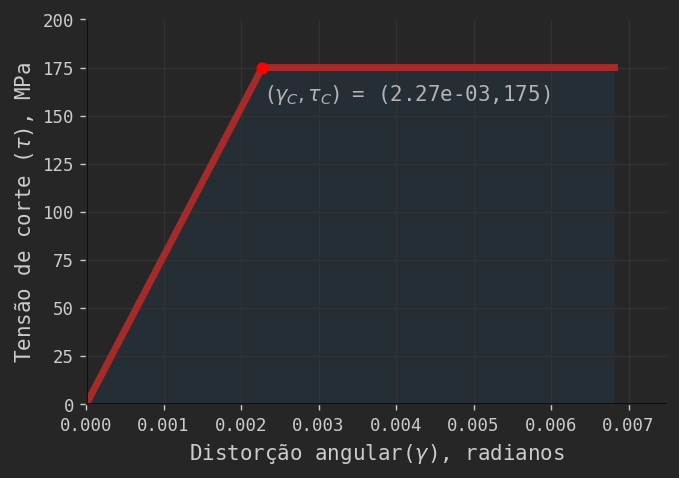

In [2]:
from matplotlib import pyplot as plt

plt.rcParams['axes.facecolor'] = (.15, .15, .15)
plt.rcParams['figure.facecolor'] = (.15, .15, .15)
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 12
# plt.rcParams['text.usetex'] = True
params = {"ytick.color" : (.8, .8, .8),
          "xtick.color" : (.8, .8, .8),
          "grid.color" : (.2, .2, .2),
          "text.color" : (.7, .7, .7),
          "axes.labelcolor" : (.8, .8, .8),
          "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

gammaC = TauC/G
print(f'gammaC (TauC) = {gammaC:.5e} | {gammaC*1e6:.1f} microdef')
xlei = np.array([0,gammaC,3*gammaC])
ylei = np.array([0,TauC*1e-6,TauC*1e-6])

fig, ax = plt.subplots(figsize=(6,4),dpi=125)
# rho in [0,rhoC]
ax.plot(xlei, ylei, '-', linewidth=4, color='brown')
plt.fill_between(xlei, ylei, alpha=.1)
plt.plot(xlei[1],ylei[1], 'ro')
x11, y11 = gammaC*1.02, TauC*1e-6*.9
ax.text(x11, y11,rf'$(\gamma_C,\tau_C)$ = ({gammaC:.2e},{TauC*1e-6:.0f})')
plt.xlabel(r'Distorção angular($\gamma$), radianos',fontsize=12)
plt.ylabel(r'Tensão de corte ($\tau$), MPa',fontsize=12)
plt.xlim(0,xlei[-1]*1.1)
plt.ylim(0,ylei[-1]*1.1)
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0,200)
ax.grid()
plt.show()

Para a análise da distribuição das tensões de corte na secção dos veios é útil reconstruir previamente o diagrama momento de torção em função do ângulo de torção, $T-\phi$. Comece-se por analisar em primeiro lugar o veio $DF$ (assume-se que o troço $FC$ pode rotar livremente como corpo rígido) e posteriormente o veio $EA$ (admite-se também que o troço $BE$ é solidário com a secção $E$).

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P001_i2.jpg"
width="600" height="400">

**Veio $DF$**

- Coordenada ($\phi_C,T_C$)

O momento de torção elástico máximo para o veio maciço $DF$, $T_C^{DF}$, é determinado pelo valor da tensão de corte admissível do material elasto-plático:

\begin{equation*}
\left(T_C = \frac{\tau_C J}{r}\right)_{DF}~,
\quad \left(J = \frac{\pi}{2}r^4\right)_{DF}
\quad\therefore\quad
T_C^{DF} = \frac{\pi}{2}\tau_Cr_{DF}^3
\end{equation*}

In [3]:
JDF = np.pi/2*rDF**4
print(f'J = {JDF:.3e} m3')
TcDF = TauC*JDF/rDF
print(f'Tc (veio DF) = {TcDF:.2f} N.m')

J = 1.473e-07 m3
Tc (veio DF) = 1473.24 N.m


De notar que,

\begin{equation*}
T_C^{DF} = \frac{\pi}{2}\tau_Cr_{DF}^3 < T
\quad \Rightarrow
\text{o veio $DF$ plastifica}
\end{equation*}

Para o valor de momento de torção máximo elástico é possível determinar o correspondente ângulo de torção crítico de acordo com a expressão (válida no domínio linear elástico):

\begin{equation*}
\left(\phi_C = \frac{T_C L}{JG}\right)_{DF}
\end{equation*}

In [4]:
phiCDF = TcDF*LDF/JDF/G
print(f'phi crítico (veio DF, TC) = {phiCDF:.6f} radianos | {np.rad2deg(phiCDF):.2f} º')

phi crítico (veio DF, TC) = 0.038961 radianos | 2.23 º


- Coordenada ($\phi,T$)

O par de coordenadas $(\phi_C,T_C)$ corresponderá ao ponto limite elástico do diagrama $T-\phi$. Para a completa construção deste diagrama é necessario agora determinar o par de coordenadas $(\phi,T)$ correspondente ao limite do regime plástico.

No domínio plástico, o momento torsor deve ser calculado considerando a seguinte integração:

\begin{equation*}
\begin{aligned}
T &= 2\pi \int_0^{\rho_C} \rho^2\left(\frac{\tau_C}{\rho_C}\rho\right)\mathrm{d}\rho +
2\pi\int_{\rho_C}^C \rho^2\tau_C\mathrm{d}\rho \\
&= \frac{2}{3}\pi c^3\tau_C\left(1-\frac{1}{4}\frac{\rho_C^3}{c^3}\right) \\
&= \frac{4}{3}T_C\left(1-\frac{1}{4}\frac{\rho_C^3}{c^3}\right) \\
&= \frac{4}{3}T_C\left(1-\frac{1}{4}\frac{\phi_C^3}{\phi^3}\right)~,
\quad\quad\text{com}\quad\frac{\rho_C}{c} = \frac{\phi_C}{\phi}
\end{aligned}
\end{equation*}

Estas equações permitem exprimir o valor do momento torsor em função de $\rho$ ou $\phi$. De notar que, no limite quando a região plástica expande da periferia para o centro da secção, i.e., $\rho_C \rightarrow 0$, o momento torsor aplicado tende para o momento plástico:

\begin{equation*}
T_P = \frac{4}{3}T_C \quad (\rho_C \rightarrow 0)
\end{equation*}

In [5]:
TpDF = 4/3*TcDF
print(f'Tp (veio DF) = {TpDF:.2f} N.m')

Tp (veio DF) = 1964.31 N.m


Desta forma pode-se concluir que o momento torsor aplicado de 1720 N.m é um valor intermédio compreendido entre o momento máximo elástico e o momento plástico:

\begin{equation*}
\therefore\quad T_C < T < T_P
\end{equation*}

Para a definição da distribuição da tensão tangencial na secção do veio $DF$ importa agora determinar qual é a fração do veio que permanece no regime

elástico e qual a fração que entretanto plastificou.

Para a construção do diagrama momento torsor-ângulo de torção ($T-\phi$) interessa também determinar o ângulo de torção gerado pela aplicação do momento torsor $T$ (no regime plástico):

\begin{equation*}
\begin{aligned}
T &= \frac{4}{3}T_C\left(1-\frac{1}{4}\frac{\phi_C^3}{\phi^3}\right)
~\Leftrightarrow~
\phi = \phi_C/\left(4-\frac{3T}{T_C}\right)^{1/3}
\end{aligned}
\end{equation*}

phi (veio DF, T) = 0.049170 radianos | 2.817 º


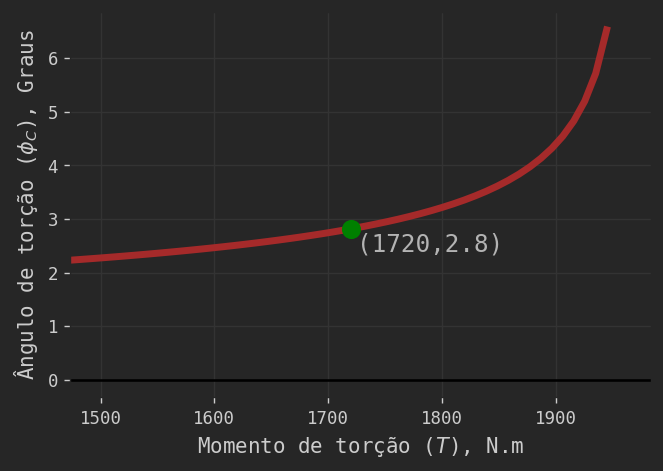

In [6]:
phiDF  = phiCDF/(4-3*T/TcDF)**(1/3)
phiDFdeg = np.rad2deg(phiDF)
print(f'phi (veio DF, T) = {phiDF:.6f} radianos | {phiDFdeg:.3f} º')

varT = np.linspace(TcDF,TpDF*.99)
varphi = np.rad2deg(phiCDF/(4-3*varT/TcDF)**(1/3))

fig, ax = plt.subplots(figsize=(6,4),dpi=125)
ax.plot(varT, varphi, '-', linewidth=4, color='brown')
ax.plot(T, phiDFdeg, 'go', markersize=10)
plt.text(T*1.003,phiDFdeg*.85,f'({T:.0f},{phiDFdeg:.1f})',fontsize=14)
plt.xlabel(r'Momento de torção ($T$), N.m',fontsize=12)
plt.ylabel(r'Ângulo de torção ($\phi_C$), Graus',fontsize=12)
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(TcDF*1.,TpDF*1.01)
# plt.ylim(0,200)
ax.grid()
plt.show()

**Momento de torção - ângulo de torção**

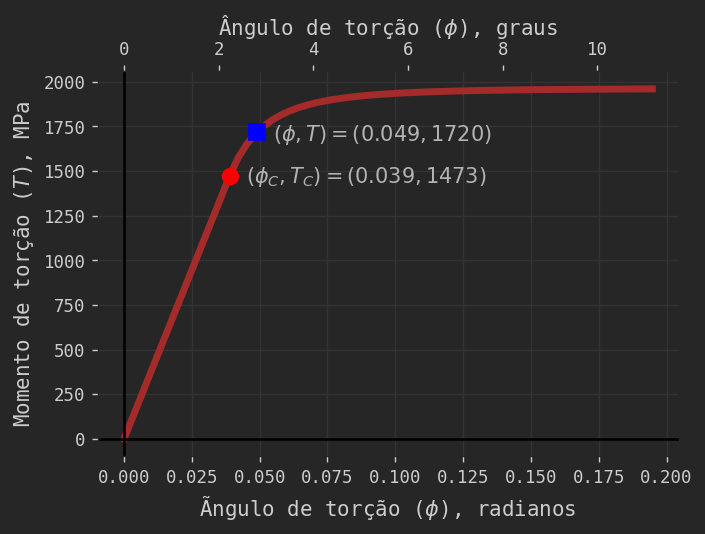

In [7]:
fig, ax = plt.subplots(figsize=(6,4),dpi=125)
# phi in [0,phiC] (elástico)
xl, yl = np.array([0,phiCDF]), np.array([0,TcDF])
ax.plot(xl,yl, '-', linewidth=4, color='brown')
# phi in [phiC,phi] (plástico)
xp = np.linspace(phiCDF,5*phiCDF,endpoint=True)
yp = 4/3*TcDF*(1-1/4*phiCDF**3/xp**3)
ax.plot(xp, yp, '-', linewidth=4, color='brown')
plt.plot(phiCDF,TcDF, 'ro',markersize=9)
ax.text(phiCDF*1.15,TcDF*.975,rf'$(\phi_C,T_C) = ({phiCDF:.3f},{TcDF:.0f})$')
plt.plot(phiDF,T, 'bs',markersize=9)
ax.text(phiDF*1.12,T*.97,rf'$(\phi,T) = ({phiDF:.3f},{T:.0f})$')
plt.xlabel(r'Ãngulo de torção ($\phi$), radianos',fontsize=12)
plt.ylabel(r'Momento de torção ($T$), MPa',fontsize=12)
# ax.set(xlabel=r'd', ylabel=r'Momento de torção ($T$), MPa')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
def deg2rad(x): return x * np.pi / 180
def rad2deg(x): return x * 180 / np.pi
secax = ax.secondary_xaxis('top', functions=(rad2deg, deg2rad))
secax.set_xlabel('Ângulo de torção ($\phi$), graus',fontsize=12)
secax.tick_params(axis='x', labelsize=10)
ax.grid()
plt.show()

**Raio crítico**

O valor do raio crítico, que define o núcleo de material no domínio elástico, circunscrito por uma coroa circular de material plástico, pode ser obtido resolvendo para $\rho$ a seguinte expressão:

\begin{equation*}
\begin{aligned}
T &= \frac{4}{3}T_C\left(1-\frac{1}{4}\frac{\rho_C^3}{c^3}\right)
~\Leftrightarrow~
\rho_C = c\left(4-\frac{3T}{T_C}\right)^{1/3}
\end{aligned}
\end{equation*}

rhoC (veio DF) = 13.87 mm


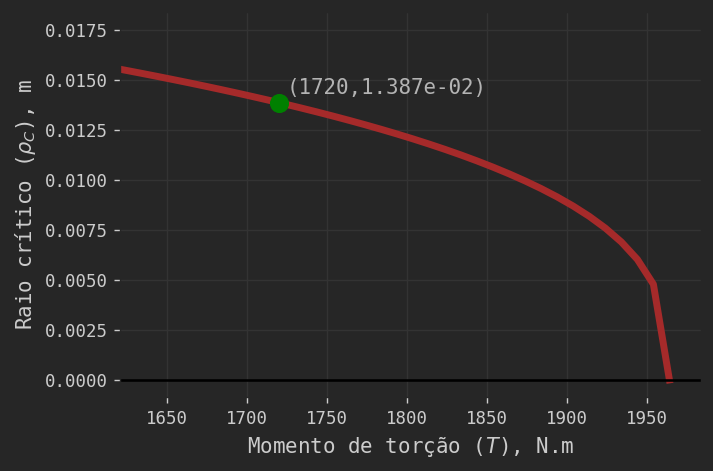

In [8]:
rhoCDF  = rDF*(4-3*T/TcDF)**(1/3)
print(f'rhoC (veio DF) = {rhoCDF*1e3:.2f} mm')

varT = np.linspace(TcDF,TpDF)
varrho = rDF*(4-3*varT/TcDF)**(1/3)

fig, ax = plt.subplots(figsize=(6,4),dpi=125)
ax.plot(varT, varrho, '-', linewidth=4, color='brown')
ax.plot(T, rhoCDF, 'go', markersize=10)
plt.text(T*1.003,rhoCDF*1.03,f'({T:.0f},{rhoCDF:.3e})',fontsize=12)
# plt.fill_between(xlei, ylei, alpha=.1)
plt.xlabel(r'Momento de torção ($T$), N.m',fontsize=12)
plt.ylabel(r'Raio crítico ($\rho_C$), m',fontsize=12)
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(TcDF*1.1,TpDF*1.01)
# plt.ylim(0,200)
ax.grid()
plt.show()

De notar que o valor do ângulo de torção poderia, em alternativa, ser obtido de:

\begin{equation*}
\frac{\phi_C}{\rho_C} = \frac{\phi}{c}
~\Leftrightarrow~
\phi \equiv \phi_{D/F} = \left(\frac{r_{DF}}{\rho_C} \right)\phi_C
~\Leftrightarrow~
\phi_{D/F} = \left(\frac{r_{DF}}{\rho_C} \right)
\left(\frac{T_C L}{J G}\right)_{DF}
\end{equation*}

In [9]:
phiDF = (rDF/rhoCDF)*TcDF*LDF/JDF/G
print(f'phi D\F = {phiDF:.4f} radianos | {np.rad2deg(phiDF):.2f} º')

phi D\F = 0.0492 radianos | 2.82 º


**Distribuição das tensões de corte**

eventually install:
conda install -c conda-forge imageio
pip install imageio


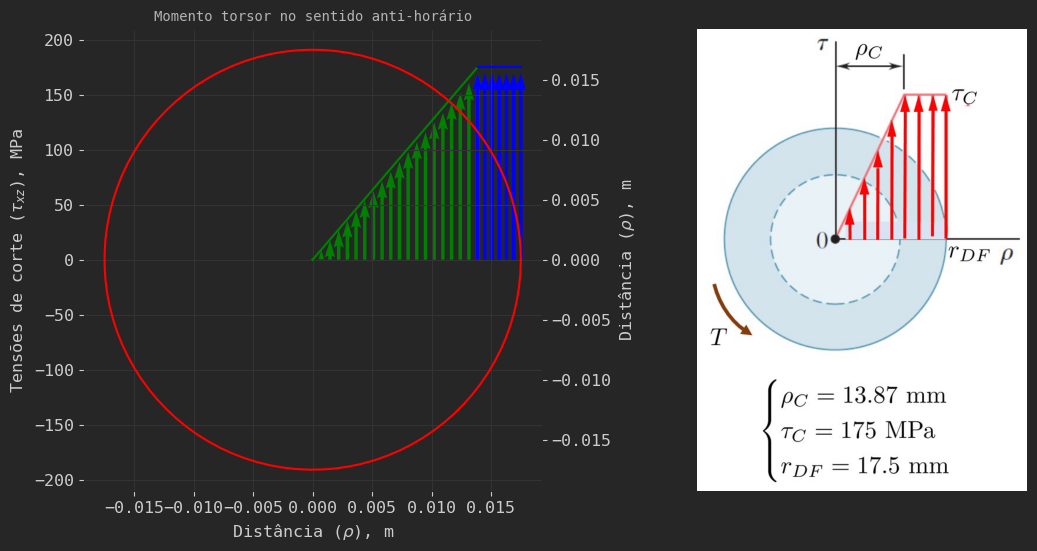

In [10]:
print("eventually install:")
print("conda install -c conda-forge imageio")
print("pip install imageio")

import imageio.v2 as iio

url1 = 'https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P001_i3.jpg'
img1 = iio.imread(url1)

limits = np.array([[-rDF*1.1,rDF*1.1],[-TauC*1.2*1e-6,TauC*1.2*1e-6]])
xp1 = np.linspace(0,rhoCDF,20)
yp1 = np.linspace(0,TauC*1e-6,20)
xp2 = np.linspace(rhoCDF,rDF,7)
yp2 = np.ones(7)*yp1[-1]

fig = plt.figure(figsize=(13,6))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(xp1,yp1,'-g')
zer = np.zeros(xp1.shape)
ax1.quiver(xp1, zer, zer, yp1, color='green',scale=430)
ax1.plot(xp2,yp2,'-b')
zer = np.zeros(xp2.shape)
ax1.quiver(xp2, zer, zer, yp2, color='blue',scale=430)
plt.xlabel(r'Distância ($\rho$), m')
plt.ylabel(r'Tensões de corte ($\tau_{xz}$), MPa')
plt.title(r'Momento torsor no sentido anti-horário',fontsize=10)
ax1.set_xlim(limits[0,0],limits[0,1])
ax1.set_ylim(limits[1,0],limits[1,1])
ax2 = ax1.twinx()
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(rDF*np.cos(theta),rDF*np.sin(theta),color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
ax2.set_ylim(limits[0,0],limits[0,1])
ax1.grid()
ax3 = fig.add_subplot(1,2,2)
plt.imshow(img1)
plt.axis('off')
plt.show()

**Veio $EA$**

**Equilíbrio estático do mecanismo**

Para analisar a torção do veio $EA$ é necessário conhecer o momento torsor transferido para o veio pela engrenagem. Para o seu cálculo é necessário analisar o equilíbrio estático dos diagramas de corpo livre associados a cada veio/engrenagem.

Da análise do equilíbrio estático do diagrama de corpo livre do veio $DF$ resulta:

\begin{equation*}
+\circlearrowleft~:~\sum M_x = 0
~\Leftrightarrow~
T - F\cdot r_F = 0
\quad\Leftrightarrow\quad
F = \frac{T}{r_F}
\end{equation*}

In [11]:
F = T/rF
print(f'F = {F:.1f} N')

F = 13760.0 N


Da análise do equilíbrio estático do diagrama de corpo livre do veio $EA$ resulta:

\begin{equation*}
+\circlearrowright~:~\sum M_x = 0
~\Leftrightarrow~
T_A - F\cdot r_E  = 0
~\quad\Leftrightarrow\quad~
T_A = F\cdot r_E = \left(\frac{r_E}{r_F}\right)  T
\end{equation*}

In [12]:
TA = F*rE
# ou: TA = rE/rF*T
print(f'TA = {TA:.1f} N.m')

TA = 688.0 N.m


- Coordenada ($\phi_C,T_C$)

Para o veio maciço $EA$, o momento elástico máximo admissível é obtido de acordo com a fórmula de torção:

\begin{equation*}
\left(T_C = \frac{\tau_C J}{r}\right)_{EA}~,
\quad J = \frac{\pi}{2}r_{EA}^4\quad\therefore\quad
T_C^{EA} = \frac{\pi}{2}\tau_Cr_{EA}^3
\end{equation*}

In [13]:
JEA = np.pi/2*rEA**4
print(f'J = {JEA:.3e} m3')
TcEA = TauC*JEA/rEA
print(f'Tc (veio AB) = {TcEA:.2f} N.m')

J = 7.952e-08 m3
Tc (veio AB) = 927.75 N.m


De notar que,

\begin{equation*}
T_C^{EA} = \frac{\pi}{2}\tau_Cr_{EA}^3 > T_A
\quad \Rightarrow
\text{veio $AB$ com comportamento elástico}
\end{equation*}

O valor crítico do ângulo de torção, $\phi_C$, associado ao mmomento máximo elástio, $T_C$, é calculado por:

\begin{equation*}
\left(\phi_{C} = \frac{T_C L}{JG}\right)_{EA}
\end{equation*}

In [14]:
phiCEA = TcEA*LEA/JEA/G
print(f'phiEA crítico (Tc veio AE) = {phiCEA:.4f} radianos | {np.rad2deg(phiCEA):.2f} º')

phiEA crítico (Tc veio AE) = 0.0303 radianos | 1.74 º


- Coordenada ($\phi_{E/A},T_{E/A}$)

Para o momento torsor $T_A \equiv T_{E/A}$ (diagrama de esforço do momento torsor ao longo do veio $EA$ é constante e iqual ao momento torsor de reação no encastramento em $A$), resultante da aplicação do momento de torção $T$ na secção $D$, a tensão de corte máxima instalada no veio $EA$ é:

\begin{equation*}
\tau = \frac{T_Ar_{EA}}{J_{EA}}
\quad\wedge\quad
J = \frac{\pi}{2}r_{EA}^4
\qquad\therefore\qquad
\tau = \frac{2T_A}{\pi r_{EA}^3}
\end{equation*}

In [15]:
tauEA = TA*rEA/JEA
print(f'tau max. (veio AB) (regime elástico) = {tauEA*1e-6:.2f} MPa')

tau max. (veio AB) (regime elástico) = 129.78 MPa


Por fim calcule-se a rotação imposta no veio $EA$ pelo momento torsor aplicado $T_A$. Sendo a secção $A$ do veio $EA$ encastrada, o ângulo de torção $\phi_E$ (da engrenagem $E$) é igual ao ângulo de torção do próprio veio $EA$:

\begin{equation*}
\left(\phi_{E/A} \equiv \phi_{E} = \frac{T_A L}{JG}\right)_{EA}
\end{equation*}

In [16]:
phiE = TA*LEA/JEA/G
print(f'phiE = {phiE:.4f} radianos | {np.rad2deg(phiE):.2f} º')

phiE = 0.0225 radianos | 1.29 º


**Momento de torção - ângulo de torção**

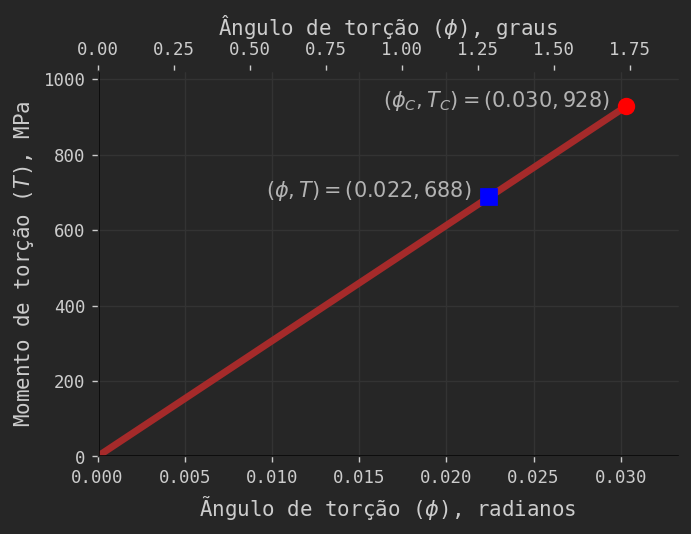

In [17]:
phi1, tau1 = phiCEA, TcEA
phi2, tau2 = phiE, TA

fig, ax = plt.subplots(figsize=(6,4),dpi=125)
xl, yl = np.array([0,phi1]), np.array([0,tau1])
ax.plot(xl,yl, '-', linewidth=4, color='brown')
plt.plot(phi1,tau1, 'ro',markersize=9)
ax.text(phi1*.54,tau1,rf'$(\phi_C,T_C) = ({phi1:.3f},{tau1:.0f})$')
plt.plot(phi2,tau2, 'bs',markersize=9)
ax.text(phi2*.43,tau2,rf'$(\phi,T) = ({phi2:.3f},{tau2:.0f})$')
plt.xlabel(r'Ãngulo de torção ($\phi$), radianos',fontsize=12)
plt.ylabel(r'Momento de torção ($T$), MPa',fontsize=12)
ax.set_xlim(0,phi1*1.1)
ax.set_ylim(0,tau1*1.1)
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
def deg2rad(x): return x * np.pi / 180
def rad2deg(x): return x * 180 / np.pi
secax = ax.secondary_xaxis('top', functions=(rad2deg, deg2rad))
secax.set_xlabel('Ângulo de torção ($\phi$), graus',fontsize=12)
secax.tick_params(axis='x', labelsize=10)
ax.grid()
plt.show()

**Distribuição das tensões de corte**

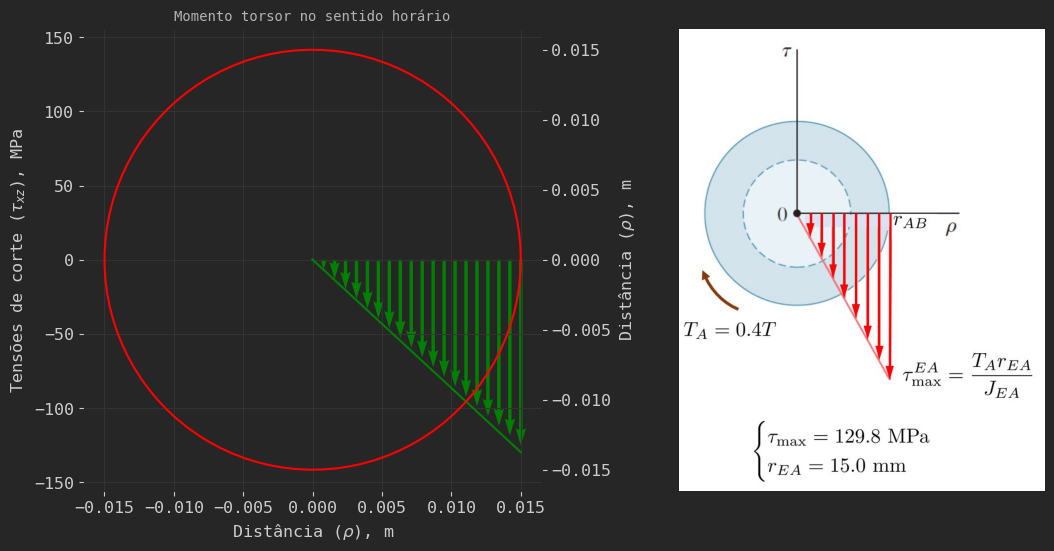

In [18]:
url2 = 'https://userweb.fct.unl.pt/~jmc' \
       '.xavier/MSI/Notebooks/Au13/Au13_P001_i4.jpg'
img2 = iio.imread(url2)

limits = np.array([[-rEA*1.1,rEA*1.1],[-tauEA*1.2*1e-6,tauEA*1.2*1e-6]])
xp1 = np.linspace(0,rEA,20)
yp1 = np.linspace(0,-tauEA*1e-6,20)

fig = plt.figure(figsize=(13,6))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(xp1,yp1,'-g')
zer = np.zeros(xp1.shape)
ax1.quiver(xp1, zer, zer, yp1, color='green',scale=320)
plt.xlabel(r'Distância ($\rho$), m')
plt.ylabel(r'Tensões de corte ($\tau_{xz}$), MPa')
plt.title(r'Momento torsor no sentido horário',fontsize=10)
ax1.set_xlim(limits[0,0],limits[0,1])
ax1.set_ylim(limits[1,0],limits[1,1])
ax2 = ax1.twinx()
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(rEA*np.cos(theta),rEA*np.sin(theta),color='red')
ax2.set(ylabel=r'Distância ($\rho$), m')
ax2.set_ylim(limits[0,0],limits[0,1])
ax1.grid()
ax3 = fig.add_subplot(1,2,2)
plt.imshow(img2)
plt.axis('off')
plt.show()

#### b) Calcule a rotação que ocorre na secção $D$ quando o momento $T$ é aplicado.<a name="B"></a> ([_enunciatum_](#PV131))

O ângulo de torção da barra $DF$ descreve a rotação relativa das secções externas do veio, ou seja:

\begin{equation*}
\phi_{D/F} = \phi_D - \phi_F \quad(\text{com:}~\phi_D \gt \phi_F)
\end{equation*}

Como o veio $DF$ entra no regime plástico, o ângulo de torção do veio $\phi_{D/F}$ deve ser calculado através de uma das relações:

\begin{equation*}
\phi_{D/F} = \left(\frac{r_{DF}}{\rho_C} \right)\phi_C
\quad\vee\quad
\phi_{D/F} = \phi_C/\left(4-\frac{3T}{T_C}\right)^{1/3}
\end{equation*}

Por sua vez, o ângulo de torção na secção $F$ (engrenagem $F$) pode relacionar-se com o ângulo de torção na secção $E$ (engrenagem $E$) de acordo com a seguinte análise cinemática,

\begin{equation*}
\begin{aligned}
\phi_F\,r_F = \phi_E\,r_E
~\Leftrightarrow~
\phi_F = \left(\frac{r_E}{r_F}\right)\phi_E
\end{aligned}
\end{equation*}

de onde se tira:

\begin{equation*}
\begin{aligned}
\phi_F  = \left(\frac{r_E}{r_F}\right) \frac{T_{A} L_{EA}}{J_{EA}G}
\end{aligned}
\end{equation*}

In [19]:
phiF = rE/rF *phiE
print(f'phiF = {phiF:.4f} radianos | {np.rad2deg(phiF):.2f} º')

phiF = 0.0090 radianos | 0.52 º


Pelo que resulta finalmente,

\begin{equation*}
\phi_D = \phi_{D/F} + \phi_F  = \phi_{D/F} + \left(\frac{r_E}{r_F}\right)\phi_E
\end{equation*}

In [20]:
phiD = phiDF + phiF
print(f'phiD = {phiD:.6f} radianos | {np.rad2deg(phiD):.3f} º')

phiD = 0.058159 radianos | 3.332 º


#### c) Considere agora que o momento T é retirado e determine a distribuição de tensões residuais nos dois veios, assim como a rotação residual sda extremidade $D$.<a name="C"></a> ([_enunciatum_](#PV131))


**Ângulo de torção residual**

O veio $EA$ é deformado em regime elástico pelo que não apresentará tensões residuais.

O veio $DF$ deforma plasticamente e após remoção do momento torsor irá sofrer deformação permanente ou residual.

O ângulo de torção residual pode ser calculado por:

No diagrama momento torsor - distorção angular ($T-\phi$) a parte de descarga do momento aplicado será representado por um segmento de reta, com declive igual ao troço linear. De notar que o ângulo de torção não volta a zero depois da remoção do momento torsor aplicado, resultando uma deformação angular permanente obtida por:

\begin{equation*}
\begin{aligned}
\phi_R = \phi_{D/F} - \phi'
\end{aligned}
\end{equation*}

com

\begin{equation*}
\phi_{D/F} =  \displaystyle\left(\frac{r_{CD}}{\rho_C} \right)\frac{T_C L_{DF}}{J_{DF} G}
\quad\wedge\quad
\phi\,{'} = \displaystyle\frac{T L_{DF} }{J_{DF}G}
\end{equation*}

em que $\phi$ é o ângulo para a aplicação da deformação plástica desenvolvida, e $\phi'$ é o ângulo recuperado na fase de descarga ($TL/JG$) (porção elástica).

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P001_i5.jpg"
width="650">

In [21]:
phidescarga  = T*LDF/JDF/G
print(f'phi(descarga) = {phidescarga:.6f} radianos | {np.rad2deg(phidescarga):.2f} º')

phiresidual = phiDF - phidescarga
print(f'phiresidual = {phiresidual:.6f} radianos | {np.rad2deg(phiresidual):.2f} º')

phi(descarga) = 0.045487 radianos | 2.61 º
phiresidual = 0.003683 radianos | 0.21 º


**Distribuição de tensões residuais**

As tensões residuais no material elastoplástico são obtidas por aplicando o princípio de superposição.

Por um lado, consideram-se as tensões devidas à aplicação do momento torsor, $T$. Por outro lado, são consideradas as tensões devido ao momento de torção, igual e oposto, que é aplicado na fase de descarga (assumindo um comportamento elástico).

O primeiro grupo de tensões reflete o comportamento elasto-plástico do material durante a fase de carregamento. O segundo grupo tem o comportamento linear do mesmo material durante o estágio de descarga. A adição dos dois grupos de tensões fornece a distribuição das tensões residuais no eixo.

Na descarga a tensão no limite elástico e na extremidade do veio podem ser obtidos por:

\begin{equation*}
\tau_1 =\tau'|_{\rho=\rho_C} = \displaystyle\frac{(-T)\rho_C}{J_{CD}}
\quad\wedge\quad
\tau_2 =\tau'|_{\rho=r_{CD}} = \displaystyle\frac{(-T)r_{CD}}{J_{CD}}
\end{equation*}

In [22]:
tau1 = -T*rhoCDF/JDF
print(f'tau1 = {tau1*1e-6:.2f} MPa')

tau2 = -T*rDF/JDF
print(f'tau2 = {tau2*1e-6:.2f} MPa')

tau1 = -161.89 MPa
tau2 = -204.31 MPa


Analisando os pontos radiais: (i) no limite do núcleo elástico do veio ($\rho_C$), (ii) na periferia do veio ($r_{CD}$), as tensões residuais vêm:

\begin{equation*}
\tau_1^R =  \tau_C + \tau_1
\quad\wedge\quad
\tau_2^R =  \tau_C + \tau_2
\end{equation*}

In [23]:
tau1R = TauC + tau1
print(f'tau1 Residual = {tau1R*1e-6:.2f} MPa')

tau2R = TauC + tau2
print(f'tau2 Residual = {tau2R*1e-6:.2f} MPa')

tau1 Residual = 13.11 MPa
tau2 Residual = -29.31 MPa


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au13/Au13_P001_i6.jpg"
width="700">

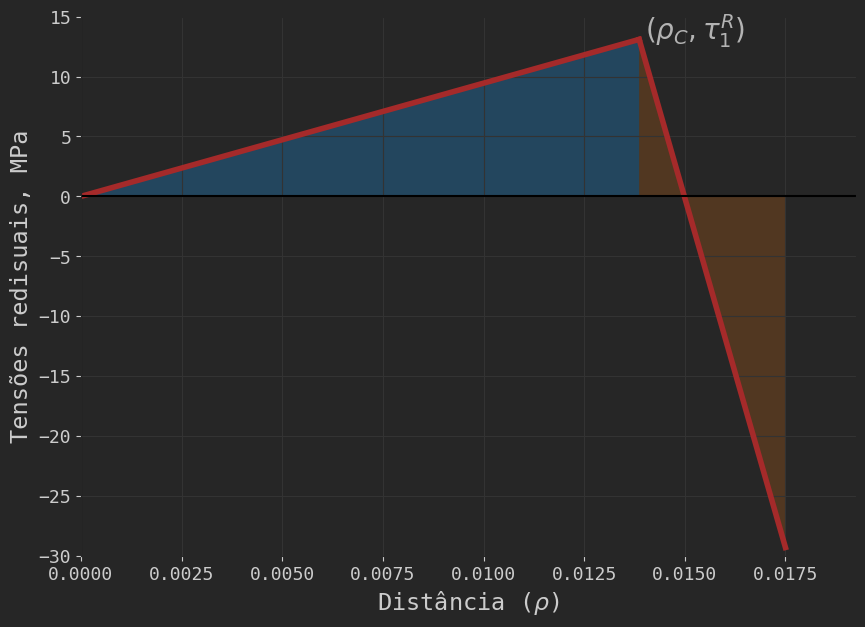

Int (0,rhoC) = 0.091
Int (rhoC,rDF) = -0.029
int rho tau dA ~ 0 : 0.061


In [24]:
xp1 = np.linspace(0,rhoCDF,100)
yp1 = np.linspace(0,tau1R*1e-6,100)

xp2 = np.linspace(rhoCDF,rDF,100)
yp2 = np.linspace(tau1R*1e-6,tau2R*1e-6,100)

params = {'axes.labelsize': 17,
         'xtick.labelsize': 13,
         'ytick.labelsize': 13}
plt.rcParams.update(params)

fig, ax = plt.subplots(figsize=(10,7))
# rho in [0,rhoC]
ax.plot(xp1, yp1, '-', linewidth=4, color='brown')
plt.fill_between(xp1,yp1, alpha=.4)
ax.text(rhoCDF*1.01, tau1R*1e-6,r'$(\rho_C,\tau_1^R)$',fontsize=20)
# rho in [rhoC,rDF]
ax.plot(xp2, yp2, '-', linewidth=4, color='brown')
plt.fill_between(xp2,yp2, alpha=.2)
ax.set(xlabel=r'Distância ($\rho$)', ylabel='Tensões redisuais, MPa')
plt.xlim(0,rDF*1.1)
plt.ylim(tau2R*1e-6*1.3,tau1R*1e-6*1.5)
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
plt.ylim(-30,15)
ax.grid()
plt.show()

IntegralT0a = np.trapz(yp1,xp1,dx = 10,axis=0)
print(f'Int (0,rhoC) = {IntegralT0a:.3f}')

IntegralT0b = np.trapz(yp2,xp2,dx = 10,axis=0)
print(f'Int (rhoC,rDF) = {IntegralT0b:.3f}')

IntegralT0 = IntegralT0a + IntegralT0b
print(f'int rho tau dA ~ 0 : {IntegralT0:.3f}')



---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
